In [1]:
#Helping methods for alpha n initialization 
from _Aplha_n_methods import Alpha_N_calc as an
from _Geometry_methods import Geometry_helper as gh

import openmc
import numpy as np
import matplotlib.pyplot as plt
import time

from scipy.interpolate import make_interp_spline
from openmc.data.endf import Evaluation, get_head_record, get_tab1_record
from concurrent.futures import ProcessPoolExecutor
from io import StringIO

def get_stopping_power_spline(mat,k=5,E_min=1e4,E_max=1e7,new_file=True):
    energies,stopping_powers = an.SR_file_write_and_read(mat,E_min=E_min,E_max=E_max,new_file=new_file)
    while k>0:    
        try:    
            spline = make_interp_spline(energies,stopping_powers,k=k,bc_type='periodic')
            break
        except:
            k-=1
            if k==1:
                spline = make_interp_spline(energies,stopping_powers,k=k)
    return spline

def get_spline_data(spline,xs,extrapolate = False,non_negative=False):
    spline_with_nan = spline(xs, extrapolate=extrapolate)
    spline_data = np.nan_to_num(spline_with_nan,nan=0.00)

    if non_negative:
        spline_data = np.clip(spline_data,0,None) #sets all negative values to zero

    return spline_data

def get_crossection_from_isotope(nuc_name,k=1,xs=None, x_min=0, x_max=8e6, plot=True,print_no_data=False):
    splines={}
    tabs={}
    failed_mts = []
    if plot:
        fig,ax = plt.subplots()
        ax.set_title(rf'{nuc_name} cross section for ($\alpha$,anything)')
        ax.set_xlabel('Energy [eV]')
        ax.set_ylabel(r'cross section [b]')
    
    for mt in np.array([4,16,17,22,23,24,25,28,29]):
        mt= int(mt)
        spline, tab ,xs = get_crosssection_spline(nuc_name,mt,k,xs,x_min,x_max)
        #print(spline, tab ,xs)
        if spline != None:
            splines[mt]=spline
            tabs[mt]=tab
            if plot:
                ax.plot(tab.x,tab.y,'x-',label=f'mt={mt}')
                ax.plot(xs,spline(xs))
        else:
            failed_mts.append(mt)
    if len(failed_mts)>0 and print_no_data:  
        print(f'In {nuc_name} following mts had no data',failed_mts)
    if plot:
        ax.legend()
    return splines,tabs

def get_crosssection_spline(nuc_name, mt,k=1, xs=None, x_min=2e6, x_max=8e6):
    #Getting data
    symbol,Z,A = an.isolate_atomic_symbol(nuc_name)
    if int(A) > 7:
        ev = Evaluation(f"/root/TENDL-a/a-{symbol}{A}.tendl")
    else:
        return None, None, None
   
    mf=3 #Reaction cross sections

    try:
        endf_output = StringIO(ev.section[mf,mt])
    except:
        #print(f'mt={mt} does not exist')
        return None,None, None
    head = get_head_record(endf_output)
    params, tab = get_tab1_record(endf_output)
    
    #print('energy',tab.x)   # energies in eV
    #print('cross section',tab.y)   # cross sections in barns

    #Removing data under x_min, over x_max and duplicates 
    mask = (tab.x >= x_min) & (tab.x <= x_max)
    tab.x = tab.x[mask]
    tab.y = tab.y[mask]
    if len(tab.x) ==0:
        #print(f'no data between {x_min} eV and {x_max} eV')
        return None,None,None
    tab.x, idx = np.unique(tab.x, return_index=True)
    tab.y = tab.y[idx]

    if xs is None:
        xs = np.linspace(min(tab.x),max(tab.x),int(1e4))
    while k>0:    
        try:    
            spline = make_interp_spline(tab.x,tab.y,k=k)
            break
        except:
            k-=1
            if k==1:
                spline = make_interp_spline(tab.x,tab.y,k=k)
    return spline, tab, xs

get_crosssection_spline('F19',4)

(<scipy.interpolate._bsplines.BSpline at 0x70351858bbd0>,
 array([2363812.        , 2364375.67516752, 2364939.35033503, ...,
        7998872.64966497, 7999436.32483248, 8000000.        ],
       shape=(10000,)))

In [2]:
#Methods running in alpha n claculater loop
def neutron_energy_alpha_n(E_a,theta,nuclide_name):
    m_a = 4.001506179127#openmc.data.atomic_mass('He4') #alpha mass
    m_n = 1.008664915904 #neutron mass
    m_T = openmc.data.atomic_mass(nuclide_name)#target nuclide
    
    Z, A, m =openmc.data.zam(nuclide_name)
    new_Z = Z+2
    m_R = openmc.data.atomic_mass(f'{openmc.data.ATOMIC_SYMBOL[new_Z]}{A+3}') #residual recoil nucleus
    
    Q_i =m_a+m_T-m_n-m_R  #From energy/mass conservation in m_T+m_a = m_n-m_R
    
    term0 = m_a*m_n*E_a*np.pow(np.cos(theta),2)/np.pow(m_n+m_R,2)
    term1 = (m_R*Q_i+(m_R-m_a)*E_a)/(m_a+m_R)
    term2 = 2*np.cos(theta)/(m_n+m_R)*np.sqrt(m_a*m_n*E_a*(m_R*Q_i+(m_R-m_a)*E_a)/(m_n+m_R))
    
    return term0 + term1 + term2

def transfer_kernel(E_a,E_n,nuclide_name):
    E_n_max = neutron_energy_alpha_n(E_a,0,nuclide_name)
    E_n_min = min([neutron_energy_alpha_n(E_a,np.pi/2,nuclide_name),neutron_energy_alpha_n(E_a,np.pi,nuclide_name)])

    if E_n < E_n_max and E_n > E_n_min:
        return 1/(E_n_max-E_n_min)
    else:
        return 0


In [3]:
#Alpha n method
class Nuclide_integrent:
    def __init__(self, E_as, nuclide_name,spline):
        self.nuclide_name = nuclide_name

        self.E_n_maxs = [neutron_energy_alpha_n(E_a, 0, nuclide_name) for E_a in E_as]
        self.E_n_mins = [min(
            neutron_energy_alpha_n(E_a, np.pi / 2, nuclide_name),
            neutron_energy_alpha_n(E_a, np.pi, nuclide_name),
        ) for E_a in E_as]
        self.values = [spline(E_a) / (E_n_max - E_n_min) for E_a,E_n_max,E_n_min in 
                      zip(E_as,self.E_n_maxs,self.E_n_mins)]
    def __call__(self, E_n,i):
        if self.E_n_mins[i] < E_n < self.E_n_maxs[i]:
            return self.values[i]
        else:
            return 0  

def init_worker(indexs, alpha_S, E_as, integrents):
    global G_indexs, G_alpha_S, G_E_as, G_integrents
    G_indexs = indexs
    G_alpha_S = alpha_S
    G_E_as = E_as
    G_integrents = integrents


def compute_spectrum(E_n):#,indexs,alpha_spectra,energies_with_alpha,integrents):
    neutrons_total = 0
    values = [np.sum([integrent(E_n,i) for integrent in G_integrents]) for i in range(len(G_E_as))]
    
    for i,alpha in zip(G_indexs,G_alpha_S): #over all different alpha energies
        neutrons_total +=  alpha*np.trapezoid(values[:i], G_E_as[:i]) #neutrons
    return neutrons_total
        
def neutron_spectra_from_material(mat,E_min=1e4,E_max=6e6,nr_points=10000,nr_energies=100,printing=True,new_file = False):

    #Getting data
    time_setup_start = time.perf_counter()
    energies = np.linspace(E_min,E_max,nr_points)
    
    mat_dens = mat.get_nuclide_atom_densities() #returns nuclide densities in atom/b-cm

    #Stopping power splines
    stopping_power_spline = get_stopping_power_spline(mat,E_min=0,E_max=E_max,new_file=new_file)
    stopping_powers=get_spline_data(stopping_power_spline,energies, extrapolate=True)
    stopping_powers = np.array(stopping_powers)*1e8 #Converting from eV/Å to eV/cm
    
    #Alpha spectrum
    alpha_decays, mass,nuclide_amount = an.alpha_decay_values_from_material(mat)
    alpha_spectra = []
    alpha_energies = []
    for name, a_activities, a_energies,energy_devs,_  in alpha_decays:
        alpha_spectra.extend(a_activities)
        alpha_energies.extend(a_energies)
    #sorting energies
    alpha_spectra = [a/mass for _,a in sorted(zip(alpha_energies,alpha_spectra))]
    alpha_energies = sorted(alpha_energies)
    
    integrent_splines = []
    
    for nuc in mat.nuclides:
        #Getting crosssections
        cross_splines,tab = get_crossection_from_isotope(nuc.name,k=5,x_max=E_max,plot=False)
        
        total_crosssection = np.zeros(nr_points)
        for mt in cross_splines:
            spline_data = get_spline_data(cross_splines[mt],energies, extrapolate=False,non_negative=True)
            if mt in [4,22,23,28,29]: #(a,n+anything)
                total_crosssection += spline_data
                
            elif mt in [11,16,24,30]: #(a,2n+anything)
                total_crosssection += 2*spline_data
                
            elif mt in [17,25]: #(a,3n+anything) for up to mt=30
                total_crosssection += 3*spline_data
            else:
                print(f'reaction with mt={mt} is not know')
        #Making integrent
        target_density = mat_dens[nuc.name] #atom/b-cm 
        
        #total_crosssection is in barns
        #stopping powers is in eV/cm
        
        integrent_splines.append(make_interp_spline(energies,target_density*total_crosssection/stopping_powers,k=5))

    #Setting energy array with all alpha energies and energies in between up
    energies_with_alpha = np.unique(np.concatenate((energies,alpha_energies)))
    indexs = [np.searchsorted(energies_with_alpha, E_a, side="right") for E_a in alpha_energies]

    #Making kernels and integrent 
    numeric_integrents = [Nuclide_integrent(energies_with_alpha,nuc.name,spline) 
                          for nuc,spline in zip(mat.nuclides,integrent_splines)]
            
    
    time_setup = time.perf_counter() - time_setup_start
    if printing:
        print(f'setup done in {time_setup} s')

    #Neutron energies
    neutrons_total = 0
    neutron_spectra = []
    neutron_energies =  np.linspace(E_min,E_max,nr_energies)

    with ProcessPoolExecutor(initializer=init_worker,
                             initargs=(indexs, alpha_spectra, energies_with_alpha, numeric_integrents)) as executor:
        neutron_spectra = list(executor.map(compute_spectrum, neutron_energies))     

    neutrons_total = np.trapezoid(neutron_spectra,neutron_energies)
    return neutron_spectra,neutron_energies,neutrons_total



len target elements 5, #elements 5
SRModule done
setup done in 0.2793972169893095 s
222.29057940302292
len target elements 6, #elements 6
SRModule done
setup done in 0.3670976499997778 s
179.798171905032


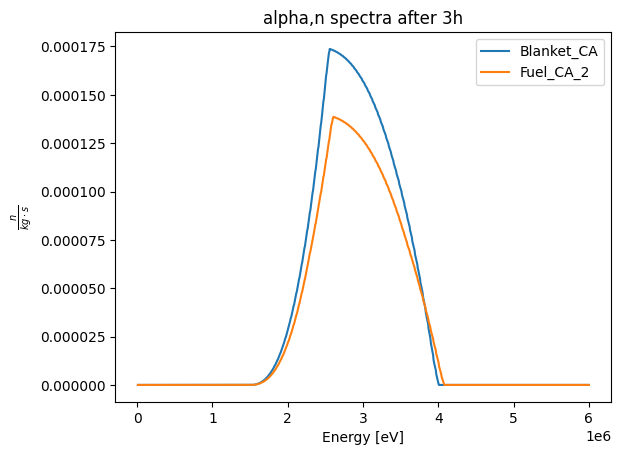

In [14]:
fig,ax =plt.subplots()

fuel_name="Blanket_CA"
mat = openmc.Materials.from_xml('materials.xml')
#mat = openmc.Materials.from_xml('Fuel_CA_2_0_h_fast.xml')
fuel = gh.get_material_by_name(fuel_name,mat)
fuel.set_density('g/cm3',4.626)
neutron_intensities,neutron_energies,total_n_per_s = neutron_spectra_from_material(fuel,E_min=1e4,nr_points=1000,nr_energies=1000,new_file=False)
ax.plot(neutron_energies,neutron_intensities,label=f'{fuel_name}')
print(total_n_per_s)

fuel_name="Fuel_CA_2"
fuel = gh.get_material_by_name(fuel_name,mat)
fuel.set_density('g/cm3',4.626)
neutron_intensities,neutron_energies,total_n_per_s = neutron_spectra_from_material(fuel,E_min=1e4,nr_points=1000,nr_energies=1000,new_file=False)
ax.plot(neutron_energies,neutron_intensities,label=f'{fuel_name}')
print(total_n_per_s)

neutron_intensities = np.clip(neutron_intensities,0,None)
energy = openmc.stats.Tabular(neutron_energies, neutron_intensities)



ax.set_title(f'alpha,n spectra after 3h')

ax.set_xlabel('Energy [eV]')
ax.set_ylabel(r'$\frac{n}{kg\cdot s}$')
ax.legend()
